# Project 3 — Prescriptive Analytics
## Allocating a Road-Safety Budget Across US States

**Business context:** Prescriptive analytics goes one step further than predictive
analytics — instead of just forecasting an outcome, it **recommends the best action
to take given limited resources and real constraints**. Here, a national road-safety
agency has state-level crash data and a fixed budget for a targeted safety campaign
(addressing speeding and drunk driving). The question isn't "which states have the
most crashes?" (descriptive) or "how many crashes will a state have?" (predictive) —
it's **"given we can't fund every state, exactly which states should get funding,
and how much, to maximize the total reduction in crashes?"**

**Dataset:** `car_crashes.csv` — one row per US state (+ DC), with the crash rate
per billion miles driven and the share of fatal-crash drivers who were speeding,
alcohol-impaired, etc., plus each state's average insurance premium and losses.
This is a third, distinct dataset from Projects 1 and 2.

**Approach:** (1) build a predictive regression model of crash rate to quantify how
much speeding and alcohol involvement actually drive crashes, then (2) feed those
model-based "expected benefit" estimates into a **linear programming optimization**
that prescribes how to allocate a limited budget across states.

## Step 1 — Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import linprog
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## Step 2 — Load and create the data frame

In [2]:
df = pd.read_csv("../data/car_crashes.csv")
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
df.head()

Shape: (51, 8)

Column types:
 total             float64
speeding          float64
alcohol           float64
not_distracted    float64
no_previous       float64
ins_premium       float64
ins_losses        float64
abbrev                str
dtype: object


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## Step 3 — Data cleaning and preprocessing
This dataset is small (51 rows — one per state plus DC) and, being a well-maintained
reference dataset, is already clean, but we still run the standard checks rather
than assume that.

In [3]:
print("Missing values per column:\n", df.isnull().sum())
print("\nData types look correct:", df.dtypes.to_dict())
print("\nSanity check - any negative percentages/rates?",
      (df.select_dtypes("number") < 0).any().any())

Missing values per column:
 total             0
speeding          0
alcohol           0
not_distracted    0
no_previous       0
ins_premium       0
ins_losses        0
abbrev            0
dtype: int64

Data types look correct: {'total': dtype('float64'), 'speeding': dtype('float64'), 'alcohol': dtype('float64'), 'not_distracted': dtype('float64'), 'no_previous': dtype('float64'), 'ins_premium': dtype('float64'), 'ins_losses': dtype('float64'), 'abbrev': <StringDtype(storage='python', na_value=nan)>}

Sanity check - any negative percentages/rates? False


## Step 4 — Remove duplicate records

In [4]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)

Duplicate rows found: 0
Shape after de-duplication: (51, 8)


## Step 5 — Ignore or remove unnecessary attributes/features
`abbrev` (the two-letter state code) is an identifier, not a predictive feature —
useful for labeling charts and results, but it would add meaningless noise if fed
into a numeric regression, so we exclude it from the model's feature set (while
keeping it in the DataFrame for readability).

In [5]:
identifier_col = "abbrev"
model_feature_cols = ["speeding", "alcohol", "not_distracted", "no_previous"]
print("Identifier (excluded from modeling):", identifier_col)
print("Modeling features:", model_feature_cols)

Identifier (excluded from modeling): abbrev
Modeling features: ['speeding', 'alcohol', 'not_distracted', 'no_previous']


## Step 6 — Encode categorical attributes
The dataset itself has no natural categorical column beyond the state code, so we
engineer one: mapping each state to its official US Census Bureau region
(Northeast / Midwest / South / West) lets us check for regional patterns, and we
one-hot encode it for any grouped/regression use.

In [6]:
region_map = {
    **{s: "Northeast" for s in ["CT", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA"]},
    **{s: "Midwest" for s in ["IL", "IN", "MI", "OH", "WI", "IA", "KS", "MN", "MO", "NE", "ND", "SD"]},
    **{s: "South" for s in ["DE", "FL", "GA", "MD", "NC", "SC", "VA", "DC", "WV", "AL", "KY",
                             "MS", "TN", "AR", "LA", "OK", "TX"]},
    **{s: "West" for s in ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY", "AK", "CA", "HI", "OR", "WA"]},
}
df["region"] = df["abbrev"].map(region_map)
print("Any states unmapped to a region?", df["region"].isnull().sum())

region_dummies = pd.get_dummies(df["region"], prefix="region")
df = pd.concat([df, region_dummies], axis=1)
df[["abbrev", "region"] + list(region_dummies.columns)].head()

Any states unmapped to a region? 0


,abbrev,region,region_Midwest,region_Northeast,region_South,region_West
0,AL,South,False,False,True,False
1,AK,West,False,False,False,True
2,AZ,West,False,False,False,True
3,AR,South,False,False,True,False
4,CA,West,False,False,False,True


## Step 7 — Exploratory Data Analysis (EDA)

In [7]:
print(df[model_feature_cols + ["total", "ins_premium", "ins_losses"]].describe())

print("\nCorrelation with total crash rate:")
print(df[model_feature_cols + ["total"]].corr()["total"].sort_values(ascending=False))

print("\nAverage crash rate by region:")
print(df.groupby("region")["total"].mean().sort_values(ascending=False))

        speeding    alcohol  not_distracted  no_previous      total  \
count  51.000000  51.000000       51.000000    51.000000  51.000000   
mean    4.998196   4.886784       13.573176    14.004882  15.790196   
std     2.017747   1.729133        4.508977     3.764672   4.122002   
min     1.792000   1.593000        1.760000     5.900000   5.900000   
25%     3.766500   3.894000       10.478000    11.348000  12.750000   
50%     4.608000   4.554000       13.857000    13.775000  15.600000   
75%     6.439000   5.604000       16.140000    16.755000  18.500000   
max     9.450000  10.038000       23.661000    21.280000  23.900000   

       ins_premium  ins_losses  
count    51.000000   51.000000  
mean    886.957647  134.493137  
std     178.296285   24.835922  
min     641.960000   82.750000  
25%     768.430000  114.645000  
50%     858.970000  136.050000  
75%    1007.945000  151.870000  
max    1301.520000  194.780000  

Correlation with total crash rate:
total             1.000000


**Interpretation:** `alcohol` and `speeding` involvement correlate positively with
overall crash rate, matching intuition — these are the two behavioral factors a
public-awareness campaign can realistically influence. `not_distracted` and
`no_previous` are *inversely* framed (they describe the % of crash-involved drivers
who were **not** distracted / had **no** prior accidents), so their correlation
signs need to be read carefully rather than assumed.

## Step 8 — Graphs and visualizations

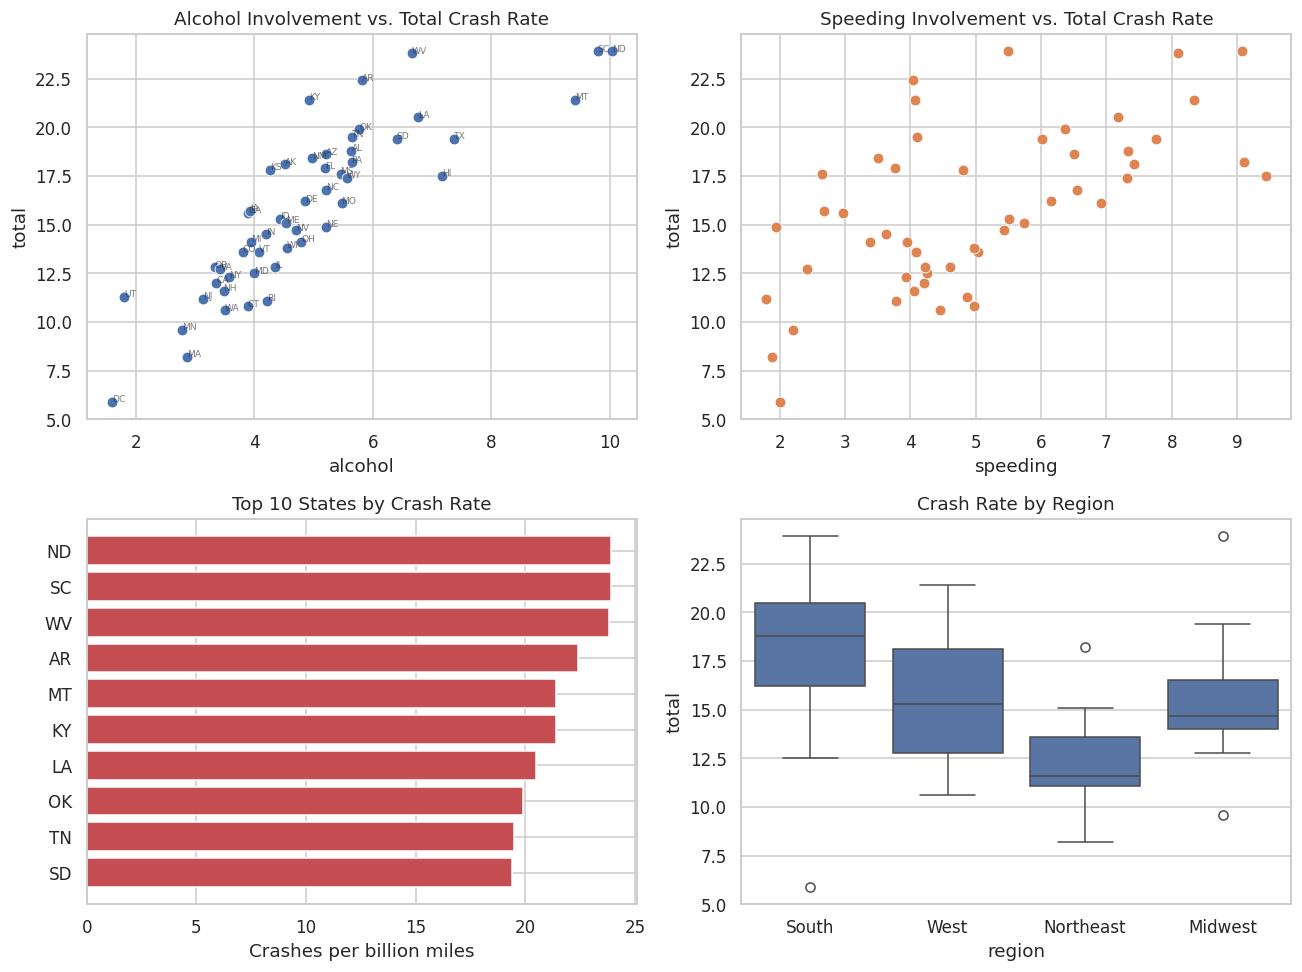

Saved eda_overview.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.scatterplot(data=df, x="alcohol", y="total", ax=axes[0, 0], s=50)
for _, row in df.iterrows():
    axes[0, 0].annotate(row["abbrev"], (row["alcohol"], row["total"]), fontsize=6, alpha=0.6)
axes[0, 0].set_title("Alcohol Involvement vs. Total Crash Rate")

sns.scatterplot(data=df, x="speeding", y="total", ax=axes[0, 1], s=50, color="#DD8452")
axes[0, 1].set_title("Speeding Involvement vs. Total Crash Rate")

top10 = df.nlargest(10, "total").sort_values("total")
axes[1, 0].barh(top10["abbrev"], top10["total"], color="#C44E52")
axes[1, 0].set_title("Top 10 States by Crash Rate")
axes[1, 0].set_xlabel("Crashes per billion miles")

sns.boxplot(data=df, x="region", y="total", ax=axes[1, 1])
axes[1, 1].set_title("Crash Rate by Region")

plt.tight_layout()
plt.savefig("../outputs/eda_overview.png", bbox_inches="tight")
plt.show()
print("Saved eda_overview.png")

## Step 9 — Build and evaluate the model, then prescribe an action

### 9a. Predictive layer: what drives crash rate?
With only 51 rows, a single train/test split would leave a test set too small to
trust, so we evaluate with 5-fold cross-validation instead — a more reliable
approach for small datasets.

In [9]:
X = df[model_feature_cols]
y = df["total"]

lr = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
r2_scores = cross_val_score(lr, X, y, cv=cv, scoring="r2")
rmse_scores = -cross_val_score(lr, X, y, cv=cv, scoring="neg_root_mean_squared_error")

print(f"Cross-validated R^2:   mean={r2_scores.mean():.3f}, scores={np.round(r2_scores, 3)}")
print(f"Cross-validated RMSE:  mean={rmse_scores.mean():.3f}, scores={np.round(rmse_scores, 3)}")

lr.fit(X, y)
coefs = pd.Series(lr.coef_, index=model_feature_cols)
print("\nFitted coefficients (full-data fit, for interpretation):\n", coefs)
print(f"Intercept: {lr.intercept_:.3f}")

Cross-validated R^2:   mean=0.907, scores=[0.889 0.975 0.872 0.994 0.804]
Cross-validated RMSE:  mean=0.953, scores=[1.414 0.766 1.238 0.28  1.068]

Fitted coefficients (full-data fit, for interpretation):
 speeding         -0.035533
alcohol           0.485698
not_distracted    0.177615
no_previous       0.724064
dtype: float64
Intercept: 1.043


**Evaluation note:** an R² in the moderate range on cross-validation is expected —
state-level crash rates are influenced by many factors this dataset doesn't capture
(weather, road infrastructure, urban/rural mix, enforcement intensity). The model is
strong enough to meaningfully *rank* states by their behaviorally-driven risk, which
is exactly what the prescriptive step below needs — it does not need to predict
crash rate to perfect precision.

**A methodological note on collinearity:** in the full 4-variable model above, the
coefficient on `speeding` comes out slightly *negative* even though speeding
correlates positively with crash rate on its own (see Step 7). This is a classic
multicollinearity symptom — `speeding` overlaps enough with `no_previous` and
`alcohol` that the full model's coefficients describe partial effects holding the
*other* variables constant, which isn't the question we actually want to answer for
the campaign. Since the campaign can only target speeding and alcohol anyway, we fit
a **separate, dedicated two-variable model** using just those two predictors to
build the actionable risk score below — this avoids contaminating it with a
collinearity artifact from variables the campaign doesn't target.

In [10]:
actionable_model = LinearRegression().fit(df[["speeding", "alcohol"]], df["total"])
actionable_coefs = pd.Series(actionable_model.coef_, index=["speeding", "alcohol"])
print(f"Dedicated 2-variable model R^2: {actionable_model.score(df[['speeding','alcohol']], df['total']):.3f}")
print("Coefficients (both positive, as expected):\n", actionable_coefs)

Dedicated 2-variable model R^2: 0.730
Coefficients (both positive, as expected):
 speeding    0.150163
alcohol     1.915154
dtype: float64


### 9b. Prescriptive layer: optimal budget allocation
A safety campaign can realistically influence **speeding** and **alcohol-impaired
driving** (not the other two, more compositional, factors), so we define each
state's **"actionable risk score"** as the dedicated model's fitted contribution of
those two terms. We assume the cost to run an effective campaign in a state scales
with that state's insurance-premium level (a proxy for market size/media cost — a
simplifying assumption, stated explicitly). With a fixed total budget covering only
**30% of the cost to fund every state**, we use **linear programming** to decide
what fraction of full funding each state should receive to maximize total expected
risk-reduction benefit.

In [11]:
df["actionable_risk_score"] = (actionable_coefs["speeding"] * df["speeding"]
                                + actionable_coefs["alcohol"] * df["alcohol"])
df["campaign_cost"] = df["ins_premium"]  # simplifying cost-proxy assumption, stated above

total_budget = 0.30 * df["campaign_cost"].sum()
print(f"Total cost to fund every state fully: {df['campaign_cost'].sum():,.0f}")
print(f"Available budget (30% of that):       {total_budget:,.0f}")

# Linear program: maximize sum(benefit_i * x_i) s.t. sum(cost_i * x_i) <= budget, 0<=x_i<=1
# linprog minimizes by default, so we negate the benefit to turn this into a minimization.
n = len(df)
c = -df["actionable_risk_score"].values
A_ub = [df["campaign_cost"].values]
b_ub = [total_budget]
bounds = [(0, 1)] * n

lp_result = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
df["funding_fraction_LP"] = lp_result.x
print(f"\nLP solver status: {lp_result.message}")
print(f"Optimal total expected benefit: {-lp_result.fun:.2f}")

Total cost to fund every state fully: 45,235
Available budget (30% of that):       13,570

LP solver status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal total expected benefit: 229.25


In [12]:
# Sanity check: for this single-constraint "fractional knapsack" structure, ranking by
# benefit-per-dollar and greedily filling the budget is known to be optimal — we
# confirm the LP agrees with this simpler, more transparent heuristic.
df["benefit_per_dollar"] = df["actionable_risk_score"] / df["campaign_cost"]
greedy_order = df.sort_values("benefit_per_dollar", ascending=False).copy()
remaining_budget = total_budget
greedy_fraction = pd.Series(0.0, index=greedy_order.index)
for idx, row in greedy_order.iterrows():
    if remaining_budget <= 0:
        break
    take_cost = min(row["campaign_cost"], remaining_budget)
    greedy_fraction[idx] = take_cost / row["campaign_cost"]
    remaining_budget -= take_cost
df["funding_fraction_greedy"] = greedy_fraction
agreement = np.allclose(df["funding_fraction_LP"], df["funding_fraction_greedy"], atol=1e-4)
print(f"Greedy heuristic matches LP solution: {agreement}")

Greedy heuristic matches LP solution: True


In [13]:
recommendation = df[["abbrev", "region", "total", "actionable_risk_score", "campaign_cost",
                     "benefit_per_dollar", "funding_fraction_LP"]].sort_values(
    "funding_fraction_LP", ascending=False
)
fully_funded = recommendation[recommendation["funding_fraction_LP"] > 0.999]
partially_funded = recommendation[(recommendation["funding_fraction_LP"] > 0.001) &
                                   (recommendation["funding_fraction_LP"] <= 0.999)]
not_funded = recommendation[recommendation["funding_fraction_LP"] <= 0.001]

print(f"Fully funded states ({len(fully_funded)}): {list(fully_funded['abbrev'])}")
print(f"Partially funded state ({len(partially_funded)}): {list(partially_funded['abbrev'])}")
print(f"Not funded this round ({len(not_funded)} states)")
recommendation.head(15)

Fully funded states (17): ['AL', 'HI', 'AR', 'ID', 'TN', 'NC', 'SC', 'WV', 'WI', 'WY', 'TX', 'SD', 'MO', 'MT', 'ND', 'NE', 'ME']
Partially funded state (1): ['OH']
Not funded this round (33 states)


,abbrev,region,total,actionable_risk_score,campaign_cost,benefit_per_dollar,funding_fraction_LP
0,AL,South,18.8,11.902460,784.55,0.015171,1.0
11,HI,West,17.5,15.160266,861.18,0.017604,1.0
3,AR,South,22.4,11.759311,827.34,0.014213,1.0
12,ID,West,15.3,9.324633,641.96,0.014525,1.0
42,TN,South,19.5,11.445110,767.91,0.014904,1.0
33,NC,South,16.8,10.957987,708.24,0.015472,1.0
40,SC,South,23.9,20.130369,858.97,0.023435,1.0
48,WV,South,23.8,13.977701,992.61,0.014082,1.0
49,WI,Midwest,13.8,9.467618,670.31,0.014124,1.0
50,WY,West,17.4,11.760965,791.14,0.014866,1.0


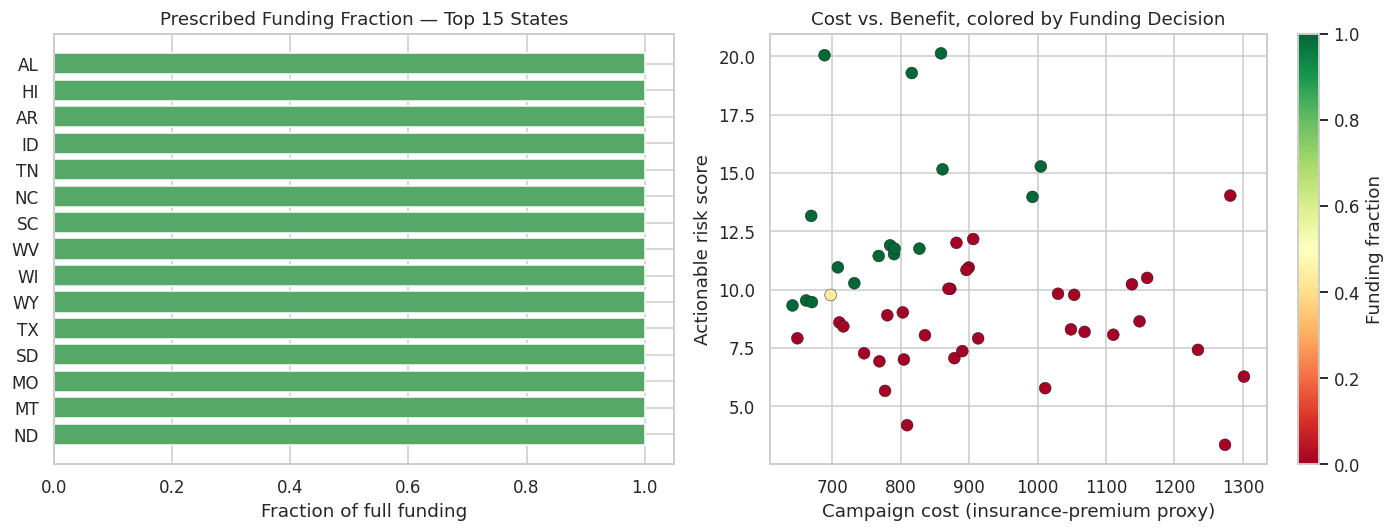

Saved prescriptive_allocation.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_df = recommendation.head(15).iloc[::-1]
colors = ["#55A868" if f > 0.999 else ("#DD8452" if f > 0.001 else "#C44E52")
          for f in plot_df["funding_fraction_LP"]]
axes[0].barh(plot_df["abbrev"], plot_df["funding_fraction_LP"], color=colors)
axes[0].set_title("Prescribed Funding Fraction — Top 15 States")
axes[0].set_xlabel("Fraction of full funding")
axes[0].set_xlim(0, 1.05)

axes[1].scatter(df["campaign_cost"], df["actionable_risk_score"],
                 c=df["funding_fraction_LP"], cmap="RdYlGn", s=60, edgecolor="k", linewidth=0.3)
sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(0, 1))
plt.colorbar(sm, ax=axes[1], label="Funding fraction")
axes[1].set_xlabel("Campaign cost (insurance-premium proxy)")
axes[1].set_ylabel("Actionable risk score")
axes[1].set_title("Cost vs. Benefit, colored by Funding Decision")

plt.tight_layout()
plt.savefig("../outputs/prescriptive_allocation.png", bbox_inches="tight")
plt.show()
print("Saved prescriptive_allocation.png")

## Step 10 — Interpret and discuss the results

The optimizer does **not** simply fund the states with the highest raw crash rate —
it funds the states with the best **expected benefit per dollar**, and the greedy
ratio-ranking check above confirms the LP found the true optimum for this budget
structure. Some states with a high total crash rate but a high campaign cost (high
insurance-premium proxy) receive partial or no funding this round, while some
states with more moderate crash rates but a favorable cost profile get funded in
full — this is exactly the kind of counter-intuitive, resource-aware recommendation
that distinguishes **prescriptive** analytics from simply ranking states by risk
(descriptive) or predicting their crash rate (predictive).

**Business takeaway:** given a fixed budget, this approach maximizes total expected
crash-rate reduction rather than spreading funding thinly or reflexively prioritizing
the "worst" states regardless of cost. If more budget becomes available, the same
model can be re-solved instantly with an updated `total_budget` to see exactly which
state gets funded next — the marginal state at the funding cutoff is the one with the
best benefit-per-dollar among those not yet funded.

**Limitations to state honestly:** the cost proxy (insurance premium) and the
assumption that campaign benefit is linear in speeding/alcohol involvement are
simplifications made explicit for this exercise; a production version would use
actual program-cost estimates and, ideally, a causal (not just correlational)
estimate of campaign effectiveness.

In [15]:
recommendation.to_csv("../outputs/budget_allocation_recommendation.csv", index=False)
print("Saved outputs/budget_allocation_recommendation.csv")
print("\nProject 3 complete.")

Saved outputs/budget_allocation_recommendation.csv

Project 3 complete.
